# Thematic Analysis of Clinical Trial Trends

## Objectives

- Explore is summaries under the same condition share similar themes.

## Inputs

- data/outputs/clinical_trials_clustered.csv

## Outputs

- data/outputs/clinical_trials_clustered.csv (Dataset remians unchanged)

__________

Import necessary libraries to conduct the thematic analysis.

In [3]:
# Import libraries (assistance from ChatGPT)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import pprint
from sklearn.metrics.pairwise import cosine_similarity

Load the dataset into a Pandas DataFrame.

In [5]:
# Load the dataset
df = pd.read_csv('../data/outputs/clinical_trials_clustered.csv')

# Display the first few row of the DataFrame
df.head(1)

,Unnamed: 0,Sponsor,Title,Summary,Start_Year,Start_Month,Phase,Enrollment,Status,Condition,Start_Month_Name,Start_Year_Period,Enrolled_Participants,Condition_cleaned,Condition_cluster,Condition_grouped
0,0,GSK,"An Open-Label, Non-Randomized Pharmacokinetic ...",The main purpose of this study is to compare h...,2006,9,Phase 1,29,Completed,"Purpura, Thrombocytopenic, Idiopathic",September,2006-2010,<50,purpura thrombocytopenic idiopathic,0,Other


Group the summaries by condition.

In [6]:
# Group the summaries by condition (assistance from ChatGPT)
grouped_summaries = df.groupby('Condition_grouped')['Summary'].apply(lambda x: ' '.join(x.dropna())).reset_index()

Clean and vectorize the text using TF-IDF to capture keywords per condition.

In [7]:
# Vectorize the grouped text
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X = vectorizer.fit_transform(grouped_summaries['Summary'])


Extract the top keywords per condition, to help see what each condition is focusing on. 

In [13]:
# Extract the top keywords per condition
feature_names = vectorizer.get_feature_names_out()

top_n = 20  # top 20 keywords
keywords_per_condition = {}

for i, row in enumerate(X.toarray()):
    top_indices = row.argsort()[::-1][:top_n]
    keywords = [feature_names[j] for j in top_indices]
    condition = grouped_summaries['Condition_grouped'].iloc[i]
    keywords_per_condition[condition] = keywords


Generate WordClouds contaning the top keywords for each goruped conditin based on the TF-IDF scores, displaying each word a size proportional to its importance. The WordClouds give a visual thematic snapshot of what each clinical trail that falls wihtin the grouped condition is focusing on.

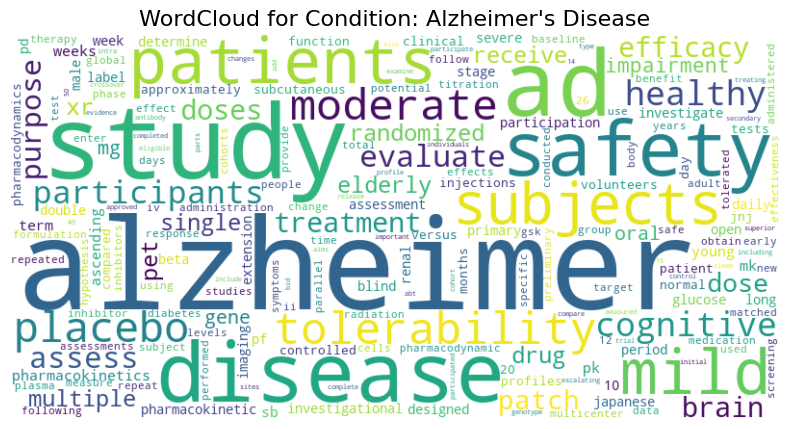

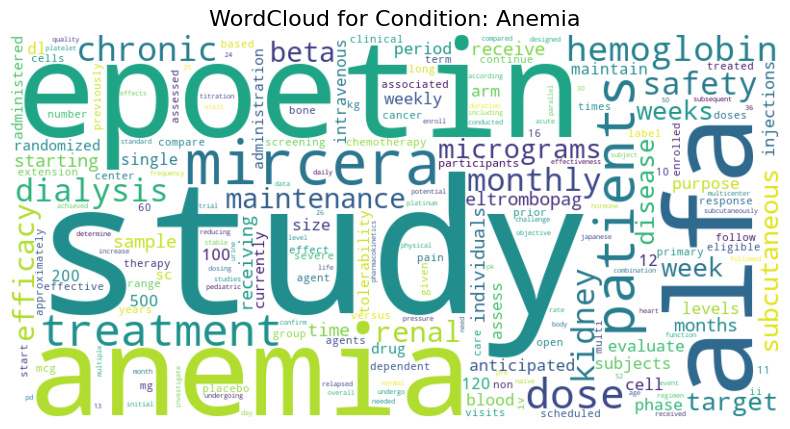

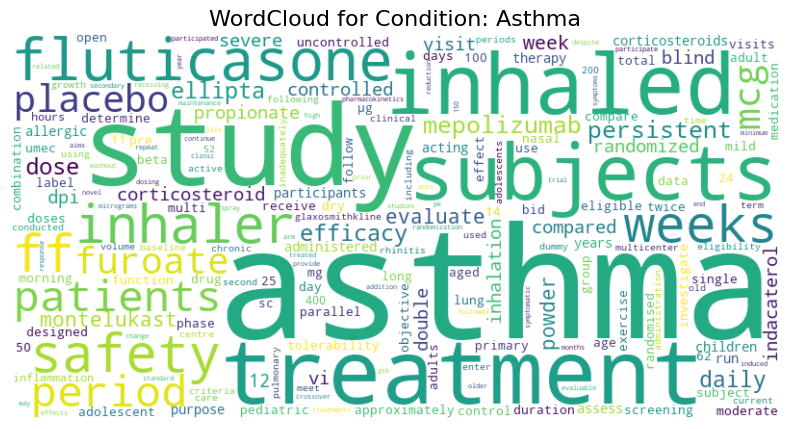

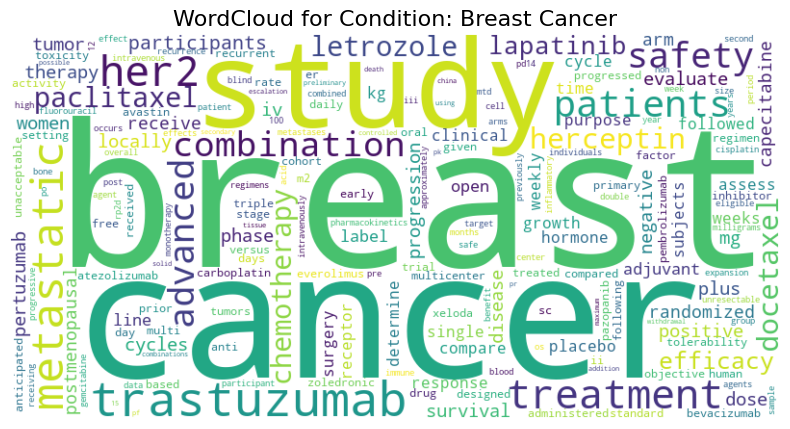

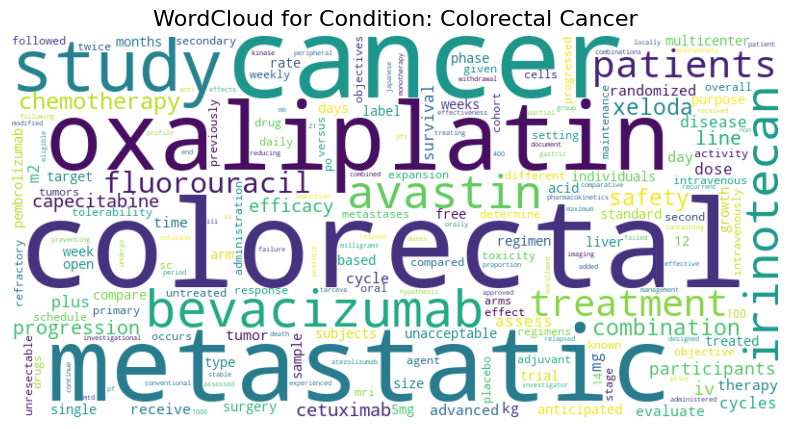

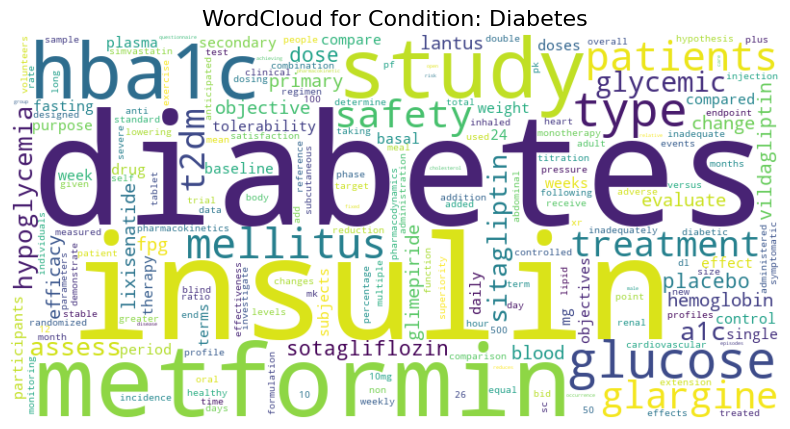

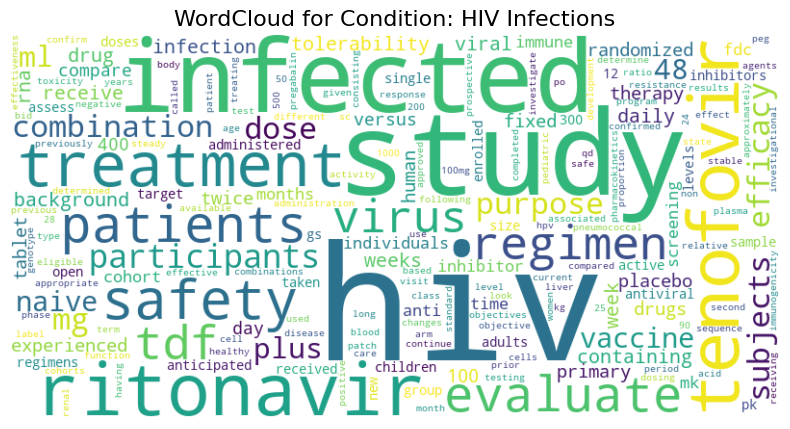

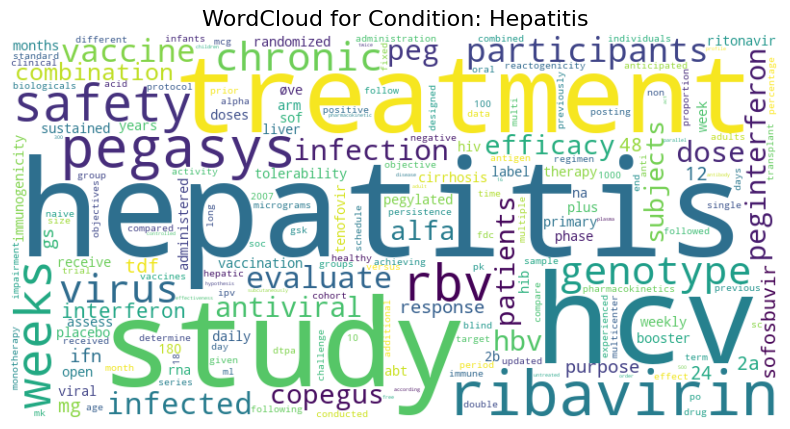

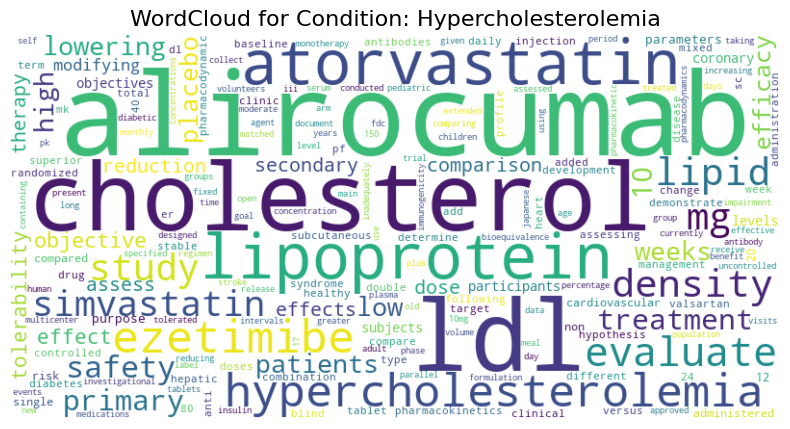

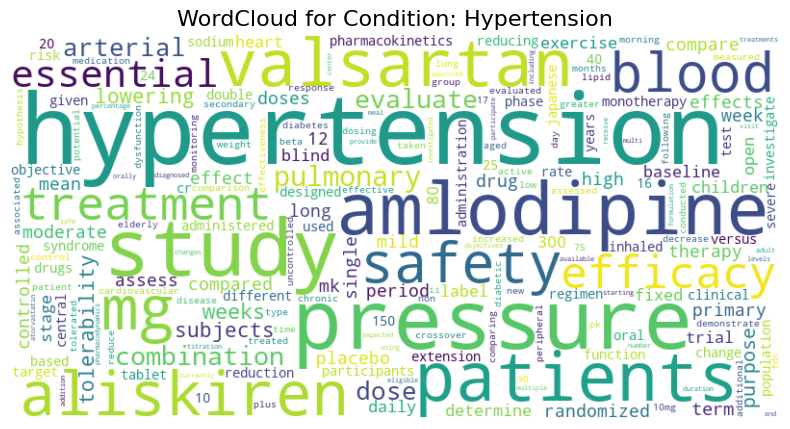

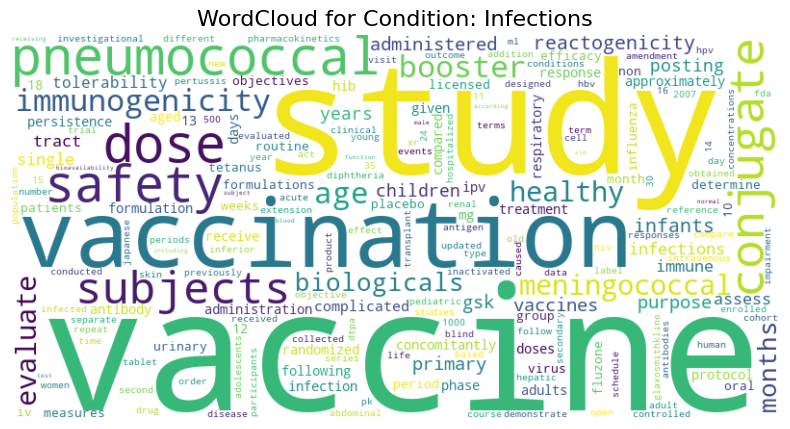

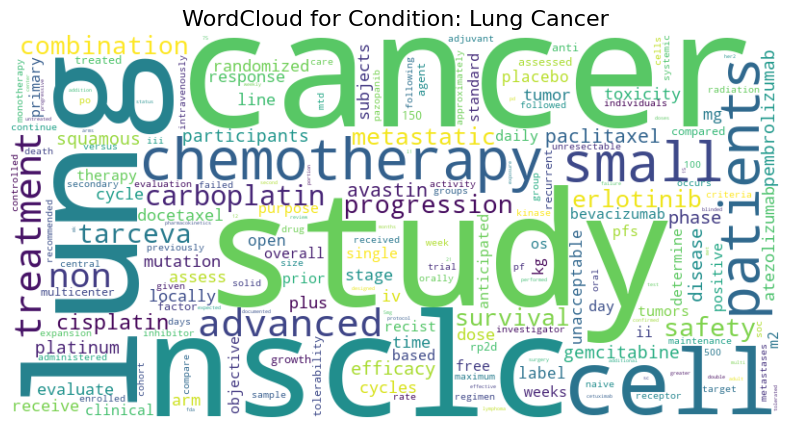

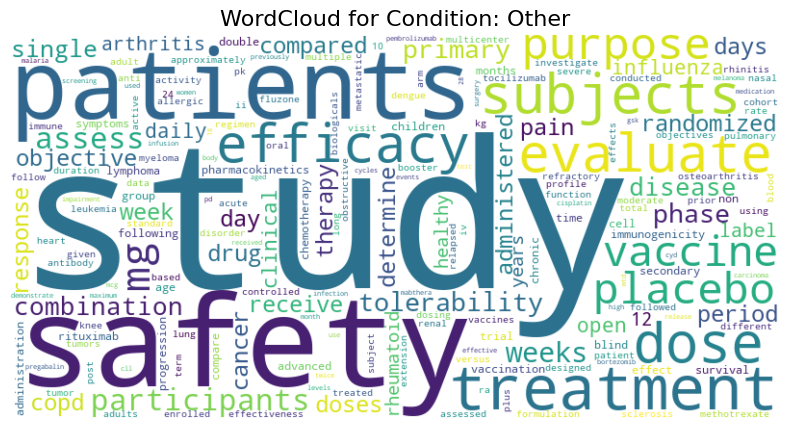

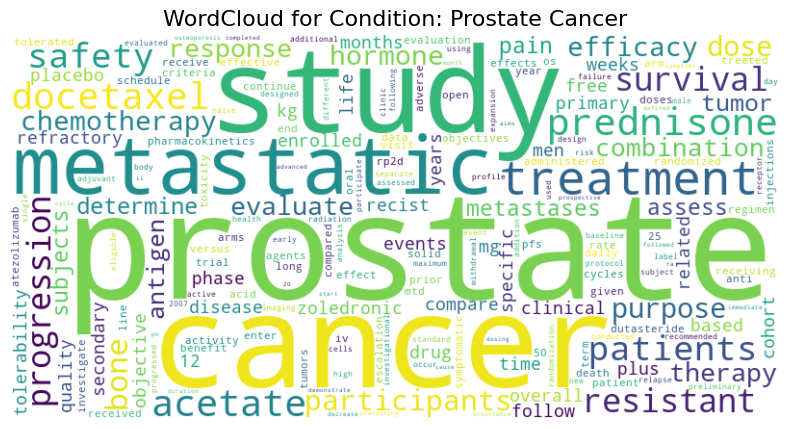

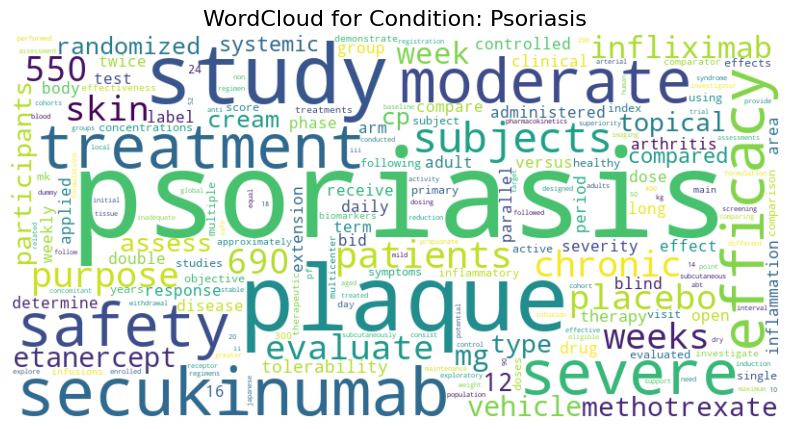

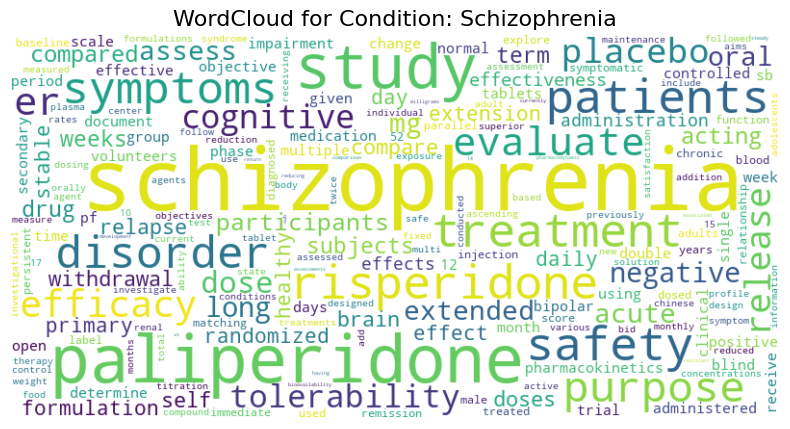

In [12]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Loop through each condition and create a wordcloud using actual TF-IDF scores (ChatGPT code creation)
for i, row in enumerate(X.toarray()):
    condition = grouped_summaries['Condition_grouped'].iloc[i]
    tfidf_scores = {feature_names[j]: row[j] for j in row.nonzero()[0]}  # Only non-zero scores

    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(tfidf_scores)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud for Condition: {condition}", fontsize=16)
    plt.show()


### **Condition - Alzheimer's Disease:**

**Top Keywords:**
alzheimer, disease, patients, study, saftey, subjects, tolerability, cognitive, treeatment, placebo

**Themes Idenitfied:**
Alzheimer Disease clinical trials are carried out with patient-centric research by focusing on several elements such as their saftey, tolerability and cognitive health. Keywords like "mild" and "moderate" suggest a focus on early stages of the disease for the trials. Additionally, terms like "doses", "patch" and "pharmacokinetics" inidcate research into drug delivery methods and mechanisms.

### **Condition - Anemia:**

**Top Keywords:**
epoetin, study, anemia, patients, treatment, saftey, dialysis, hemoglobin, dose, monthly

**Themes Idenitfied:**
Trials have a patient-centric focus, highlighted by keywords like "patients" and "safety". Terms such as "dialysis" suggest a significant number of trials target anemia patients with kidney-related conditions to enrol. Keywords such as "monthly" and "dose" indicate research into optimal dosing schedules administration methods. 

### **Condition - Asthma:**

**Top Keywords:**
asthma, study, treatment, safety, subjects, inhaled, fluticasone, inhaler, weeks, efficay

**Themes Idenitfied:**
Keywords such as "inhaled", "inhaler", "weeks" and "fluticasone" suggest the trials have a strong focus on inhalation based therapies and investigation the efficacy. Moreover, thery indicate research into treatment schedules and durations. 

### **Condition - Breast Cancer:**

**Top Keywords:**
breast, cancer, study, safety, patients, treatment, trastuzumab, metastatic, combination, Her2

**Themes Idenitfied:**
Keywords like "metastatic" suggest trials focus on the later stages of breast cancer. Terms like "trastuzumab" and "combination" suggest research into speicific drugs and therapy, exploring multi-drug or multi-treatment approaches. 

### **Condition - Colorectal Cancer:**

**Top Keywords:**
colorectal, cancer, study, oxaliplatin, metastatic, patients, treatment, bevacizumab, fluorouracil, combination

**Themes Idenitfied:**
Keywords like "metastatic" suggest trials focus on the later stages of colorectal cancer. Terms such as "oxaliplatin", "bevacizumab" and "fluorouracil" suggest research into specific drugs and chemotherapy regimines. Moreover, words such as "combination" suggest exploring multi-drug or multi-treatment approaches.

### **Condition - Diabetes:**

**Top Keywords:**
diabetes, insulin, study, metformin, pateints, saftey, glucose, HbA1c, type, treatment

**Themes Idenitfied:**
Trials focus on evaluationg the efficacy and safety of treatments/drugs like "insulin" and "metformin". Terms like "glucose", "HbA1c" highlight the focus on managing blood sugar levels effectively. Keywords like "type" suggest trials explore different types of diabetes and don't just focus on one. 

### **Condition - HIV Infections:**

**Top Keywords:**
HIV, infected, study, treatment, patients, safety, ritonavir, tenofovir, regimen, virus

**Themes Idenitfied:**
Keywords like "ritonavir" and "tenofovir" highlight research into specific antiretrovital drugs and possibly their effectiveness. Moreover, terms like "regimen" and "combination" suggest trials exploring combination therapy approaches and administration. 

### **Condition - Hepatitis:**

**Top Keywords:**
hepatitis, study, treatment, safety, virus, ribavirin, peginterferon, participnats, genotype, weeks

**Themes Idenitfied:**
Keywords like "ribavirin" and "peginterferon" suggest research into specific antiviral drugs and their effectiveness. Moreover, terms like "weeks" and "treatment" suggest research into treatment schedules and durations. Keywords such as "genotype" inidcate different trials target specific hepatitis strains. Additionally, "vaccine" and "vaccination" indicate research into preventative measures alongside treatment.